In [2]:
#IMPORTS
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
# Load Dataset
df = pd.read_csv(r"C:\\Users\\Seher\\Desktop\\DA TASK 9\\house_prices.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (300, 8)


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [7]:
#Basic information
# Data Info
df.info()

# Statistical Summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB


,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


In [8]:
# Check missing values
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

Missing Values:
Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64


In [9]:
# Remove ID column
df = df.drop(columns=["Property_ID"])

df.head()

,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,3712,4,3,36,Rural,House,22260000
1,1591,4,1,35,Suburb,House,16057500
2,1646,4,3,20,Rural,Villa,12730000
3,4814,1,2,13,City Center,Villa,50840000
4,800,4,2,38,Suburb,Apartment,10650000


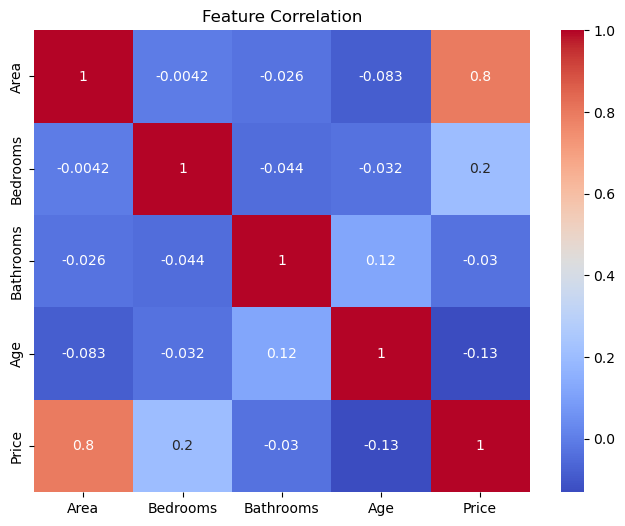

In [10]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

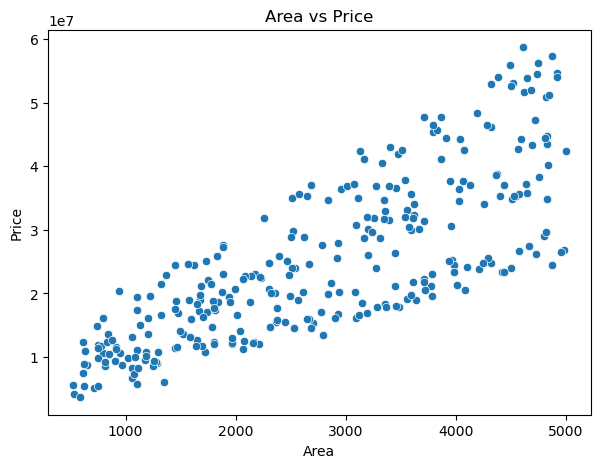

In [11]:
#Scatter Plot

plt.figure(figsize=(7,5))

sns.scatterplot(x=df["Area"], y=df["Price"])

plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

In [12]:
# Separate features and target

X = df.drop("Price", axis=1)
y = df["Price"]

# Identify categorical and numerical columns

categorical_features = ["Location", "Property_Type"]
numerical_features = ["Area", "Bedrooms", "Bathrooms", "Age"]

In [13]:
# Preprocessing

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [14]:
#train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (240, 6)
Testing Size: (60, 6)


In [15]:
# Pipeline with Linear Regression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

pred_linear = linear_model.predict(X_test)

In [17]:
#Evaluation Metrics

mae = mean_absolute_error(y_test, pred_linear)
mse = mean_squared_error(y_test, pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_linear)

print("LINEAR REGRESSION PERFORMANCE")

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

LINEAR REGRESSION PERFORMANCE
MAE: 2188736.3437038083
MSE: 8454330868276.761
RMSE: 2907633.207314286
R2 Score: 0.940637118511223


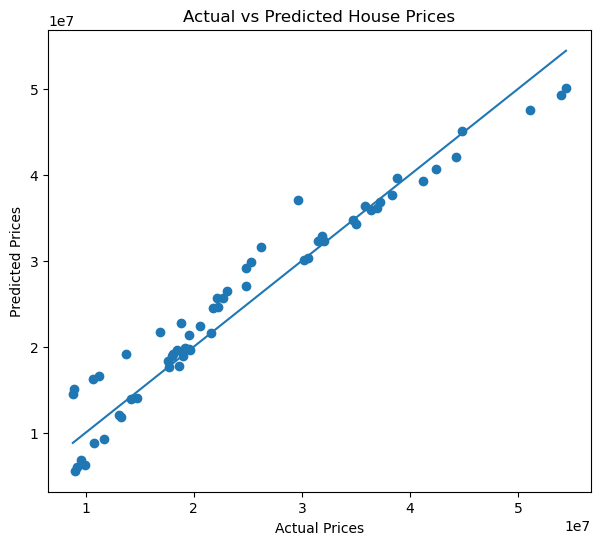

In [18]:
#Prediction vs Actual

plt.figure(figsize=(7,6))

plt.scatter(y_test, pred_linear)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.savefig("predictions_vs_actual.png")

plt.show()

In [19]:
#Polynomial Regression

poly_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LinearRegression())
])

poly_pipeline.fit(X_train, y_train)

pred_poly = poly_pipeline.predict(X_test)

print("Polynomial R2 Score:", r2_score(y_test, pred_poly))

Polynomial R2 Score: 1.0


In [20]:
#Decision Tree Regressor

tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=6,
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_train)

pred_tree = tree_pipeline.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, pred_tree))

Decision Tree R2: 0.9325711610304638


In [21]:
#Random Forest Regressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

pred_rf = rf_pipeline.predict(X_test)

print("Random Forest R2:", r2_score(y_test, pred_rf))

Random Forest R2: 0.9731538904867374


In [22]:
#Model Comparison

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, pred_linear),
        r2_score(y_test, pred_poly),
        r2_score(y_test, pred_tree),
        r2_score(y_test, pred_rf)
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
1,Polynomial Regression,1.000000
3,Random Forest,0.973154
0,Linear Regression,0.940637
2,Decision Tree,0.932571


In [23]:
# FINAL MODEL SUMMARY OUTPUT

# Get feature importance from Random Forest

rf_model = rf_pipeline.named_steps["model"]

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(3)

print("======================================")
print("      HOUSE PRICE PREDICTION MODEL    ")
print("======================================\n")

print(f"MAE: ${mae:,.0f}")
print(f"MSE: {mse:.2e}")
print(f"R² Score: {r2:.2f}\n")

print("Best Features:")

for feature in top_features["Feature"]:
    print(feature)

      HOUSE PRICE PREDICTION MODEL    

MAE: $2,188,736
MSE: 8.45e+12
R² Score: 0.94

Best Features:
num__Area
cat__Location_City Center
cat__Location_Rural
